In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# DE10YT

In [50]:
df_bund = pd.read_excel('./Dataset/Macro/DE10YT=RR.xlsx')
df_numeric = df_bund[['Bid', 'Ask', 'BidYld', 'AskYld']].dropna()
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

             Bid       Ask    BidYld    AskYld
Bid     1.000000  0.999239 -0.187696 -0.188421
Ask     0.999239  1.000000 -0.183865 -0.184763
BidYld -0.187696 -0.183865  1.000000  0.998888
AskYld -0.188421 -0.184763  0.998888  1.000000


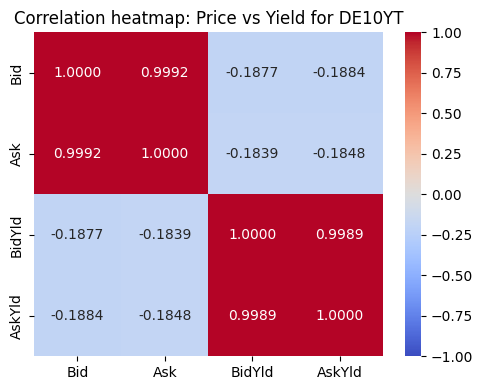

In [51]:
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation heatmap: Price vs Yield for DE10YT")
plt.tight_layout()
plt.savefig('./Correlations/DE10YT.png')

In [52]:
X = df_numeric.copy()
X['Constant'] = 1 

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data[vif_data['Variable'] != 'Constant']

print("\n")
print(vif_data.to_string(index=False))



Variable        VIF
     Bid 670.213799
     Ask 669.333182
  BidYld 454.256906
  AskYld 453.995634


Correlation Values > 0.95 indicate extreme redundancy.

VIF: Values > 10 indicate critical multicollinearity.

Since all values are highly correlated, we can conclude that they are redundant and do not provide additional information to the model. Hence, we can keep only BidYld as the representative feature for the DE10YT macro feature.

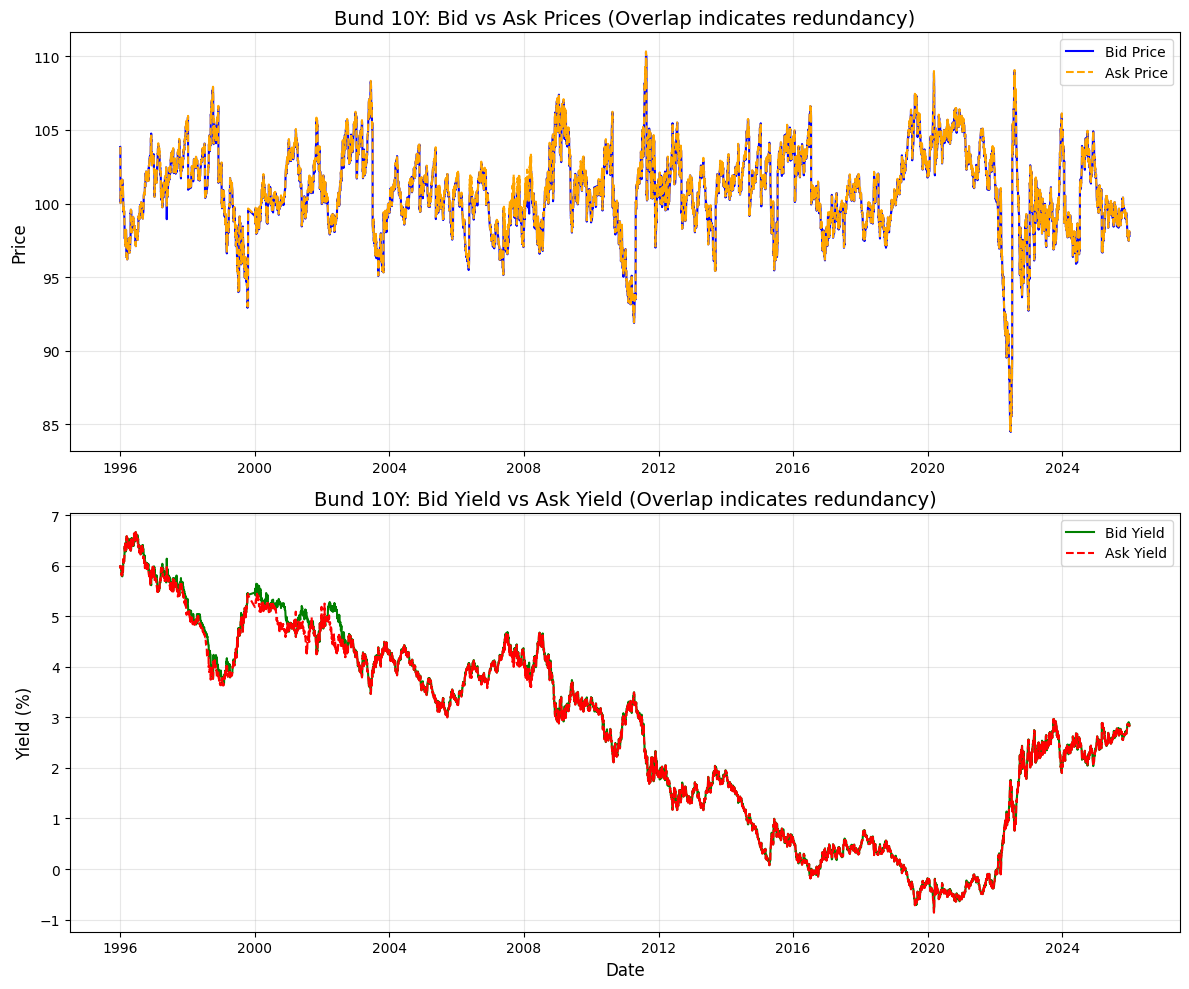

In [53]:
df_plot = df_bund.sort_values('Date').dropna(subset=['Bid', 'Ask', 'BidYld', 'AskYld'])

# Create a figure with 2 subplots (Prices on top, Yields on bottom) due to different scales
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=False)

# Plot 1: Prices (Bid vs Ask)
axes[0].plot(df_plot['Date'], df_plot['Bid'], label='Bid Price', color='blue', linewidth=1.5)
# Using dashed line for Ask so the overlap is visually obvious
axes[0].plot(df_plot['Date'], df_plot['Ask'], label='Ask Price', color='orange', linewidth=1.5, linestyle='--')
axes[0].set_title('Bund 10Y: Bid vs Ask Prices (Overlap indicates redundancy)', fontsize=14)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Yields (BidYld vs AskYld)
axes[1].plot(df_plot['Date'], df_plot['BidYld'], label='Bid Yield', color='green', linewidth=1.5)
# Using dashed line for AskYld
axes[1].plot(df_plot['Date'], df_plot['AskYld'], label='Ask Yield', color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Bund 10Y: Bid Yield vs Ask Yield (Overlap indicates redundancy)', fontsize=14)
axes[1].set_ylabel('Yield (%)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('./Plots/DE10YT.png', dpi=300)
plt.show()


# IT10YT

In [54]:
df_eur = pd.read_excel('./Dataset/Macro/EUR=.xlsx')
df_eur = df_eur.rename(columns={'Exchange Date': 'Date'})
df_eur['Date'] = pd.to_datetime(df_eur['Date'], errors='coerce')

analysis_columns = ['Bid', 'Ask', 'High', 'Low', 'Open', 'Refresh Rate', 'BidNet']
df_numeric = df_eur[analysis_columns].dropna()
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce').dropna()

In [55]:
X = df_numeric.copy()
X['Constant'] = 1

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Remove the constant for printing purposes
vif_data = vif_data[vif_data['Variable'] != 'Constant']
print(vif_data.to_string(index=False))

    Variable           VIF
         Bid 770563.737958
         Ask 751991.083738
        High   2204.822428
         Low   2202.511389
        Open  15627.545534
Refresh Rate      1.027663
      BidNet     42.048287


Refresh rate shows a low VIF value, indicating that it is not highly correlated with the other features. This suggests that it may provide unique information to the model and can be retained as a valuable feature for analysis.

All the other features (Bid, Ask, High, Low, Open, BidNet) have VIF values greater than 10, indicating that they are highly correlated with each other and may cause multicollinearity issues in the model. Therefore, it is advisable to drop these features and keep only Bid among them.

                   Bid       Ask      High       Low      Open  Refresh Rate  \
Bid           1.000000  0.999999  0.999311  0.999318  0.998498     -0.104357   
Ask           0.999999  1.000000  0.999312  0.999315  0.998496     -0.104393   
High          0.999311  0.999312  1.000000  0.999067  0.999322     -0.101680   
Low           0.999318  0.999315  0.999067  1.000000  0.999313     -0.106837   
Open          0.998498  0.998496  0.999322  0.999313  1.000000     -0.104185   
Refresh Rate -0.104357 -0.104393 -0.101680 -0.106837 -0.104185      1.000000   
BidNet        0.027521  0.027537  0.000236  0.000545 -0.026630     -0.003551   

                BidNet  
Bid           0.027521  
Ask           0.027537  
High          0.000236  
Low           0.000545  
Open         -0.026630  
Refresh Rate -0.003551  
BidNet        1.000000  


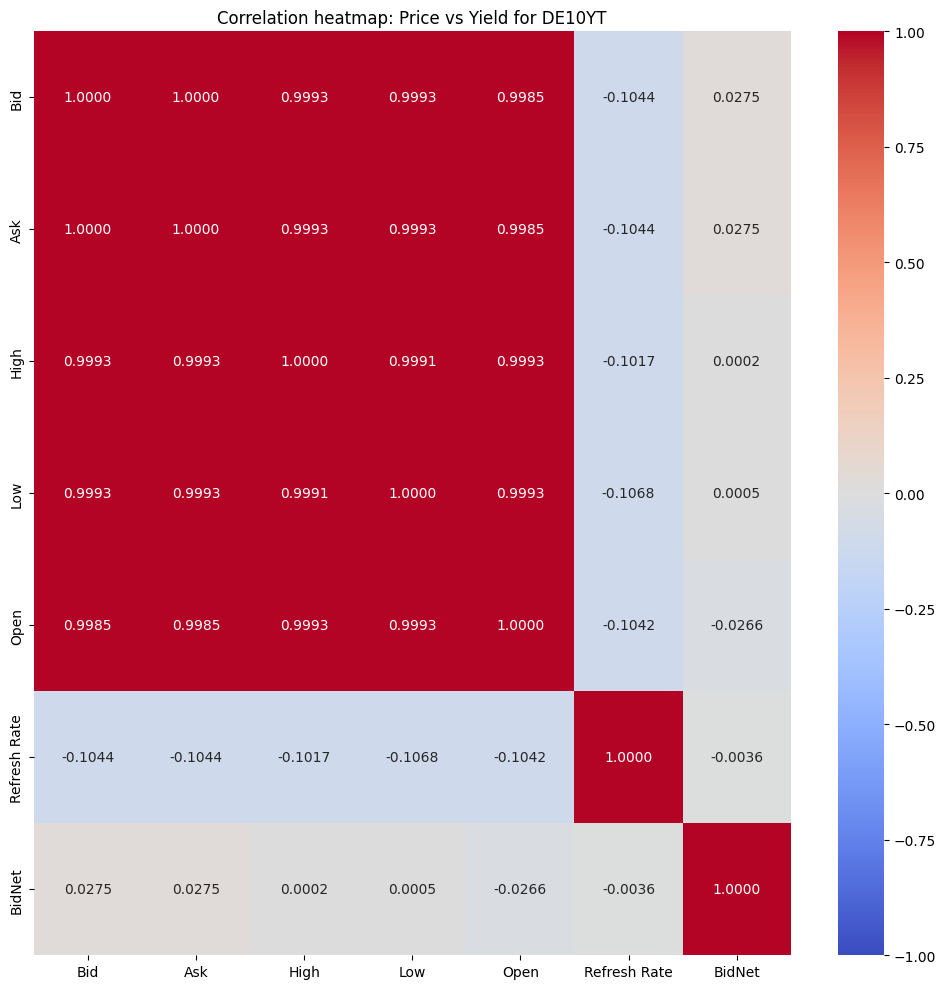

In [58]:
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title("Correlation heatmap: Price vs Yield for DE10YT")
plt.tight_layout()
plt.savefig('./Correlations/DE10YT.png')